# DNN: analysis with Keras of 2D data

# Keras Tuner 
check https://keras.io/keras_tuner/getting_started/ or just pip install keras-tuner -q 

install tensorflow 


In [3]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
#add by me:
from keras import layers
import keras.optimizers

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.8
perc_valid = 0.10
perc_test = 0.10
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

## Read data

(9000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 9000
train: 7200
valid: 900
test: 900


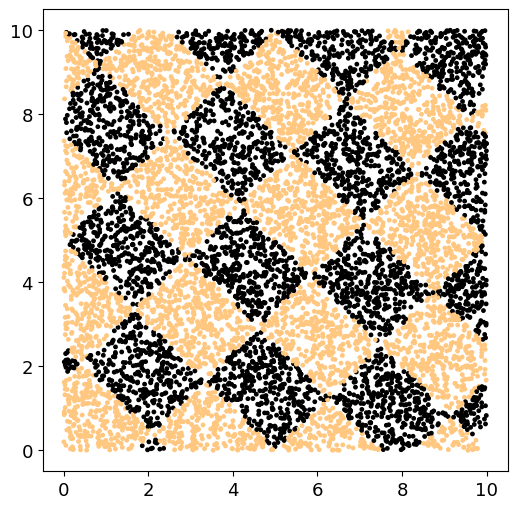

In [5]:
# Keras works with numpy arrays: just use them from the start

TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt('DATA/data-red-for-DNN_type4_L8.dat', delimiter=' ')
y = np.loadtxt('DATA/labels-red-for-DNN_type4_L8.dat', delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

## Split data and standardize (fit on train only)

In [7]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 7200 	 Validation: 900 	 Test: 900
after rescaling (train):
mean value= [ 4.97429258e-15  7.58550630e-15 -3.36221791e-15 -1.12749316e-16
 -3.14578610e-15 -2.87425947e-15 -2.72715492e-15 -2.54271912e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


## Define the model with Keras / Tensorflow

In [9]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

# We use case 1
CASE=1

if CASE==1: # 4 layers
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu')) # first layer : L=8 neurons
    model.add(Dense(20,activation='relu')) 
    model.add(Dropout(0.1)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
# as case 1 but one layer shorter
if CASE==2:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(40,activation='relu'))
    model.add(Dropout(0.1)) 
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
#deeper
if CASE==3: #deeper neural network
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
    
print(model.summary())

#how many parameters we have in our neural network?
# number of neurons, weigths and bias for each neuron, number of params = #input_units*#output_units + output_units
# case 1: 8*8+8 = 72
# we want to compare our num of params with the size of the dataset. We want num of total params < num of training sample otherwise 
# it's overfitting.

C:\Users\melis\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
#build function does not manually choose hyperparameters because it defines 
#the search space and the tuner picks the values during random search.
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice("activation", ["relu", "sigmoid", "elu"])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    
    model.add(Dense(L,input_shape=(L,),activation=activation)) # first layer : L=8 neurons
    #model.add(Dense(20,input_shape=(L,),activation=activation)) # chat says that this is the first hidden layer of 20 and
    # input_shape = (L,) tells that the input layer is made of L neurons automatically
    model.add(Dense(20,activation=activation)) 
    model.add(Dropout(dropout)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(1,activation="sigmoid"))
    #nepoch=200
    
    lr = hp.Choice("learning_rate", [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam","rmsprop","sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=lr, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
import keras_tuner

build_model(keras_tuner.HyperParameters())

<Sequential name=sequential_1, built=True>

In [12]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=30,
  #  executions_per_trial=5,
    overwrite=True,
    directory="tuner_results",
    project_name="ex_1",
)

In [13]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'elu'], 'ordered': False}
dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2], 'ordered': True}
learning_rate (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [14]:
tuner.search(x_train, y_train, epochs=50, validation_data=(x_valid, y_valid))


Trial 30 Complete [00h 00m 30s]
val_accuracy: 0.5377777814865112

Best val_accuracy So Far: 0.8766666650772095
Total elapsed time: 00h 15m 08s


In [15]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=3)
best_model = models[0]
best_model.summary()

C:\Users\melis\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\melis\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             180 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
tuner.results_summary()


Results summary
Results in tuner_results\ex_1
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 13 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: rmsprop
Score: 0.8766666650772095

Trial 07 summary
Hyperparameters:
activation: relu
dropout: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.8133333325386047

Trial 10 summary
Hyperparameters:
activation: relu
dropout: 0.1
learning_rate: 0.1
optimizer: sgd
Score: 0.601111114025116

Trial 22 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.001
optimizer: rmsprop
Score: 0.5699999928474426

Trial 09 summary
Hyperparameters:
activation: relu
dropout: 0.2
learning_rate: 0.001
optimizer: adam
Score: 0.5666666626930237

Trial 08 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.001
optimizer: adam
Score: 0.5588889122009277

Trial 06 summary
Hyperparameters:
activation: relu
dropout: 0.2
learning_rate: 0.0001
optimizer: rmsprop
Score: 0.537

In [17]:
# Get the top 2 hyperparameters.
best_hps = tuner.get_best_hyperparameters(5)
# Build the model with the best hp.
model = build_model(best_hps[0])
# Fit with the entire dataset.
#x_all = np.concatenate((x_train, x_valid))
#y_all = np.concatenate((y_train, y_valid))
#fit = model.fit(x=x_all, y=y_all, epochs=200)
fit = model.fit(x_train, y_train,
               epochs = 200, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
144/144 - 1s - 9ms/step - accuracy: 0.5065 - loss: 0.6983 - val_accuracy: 0.5167 - val_loss: 0.6923
Epoch 2/200
144/144 - 0s - 2ms/step - accuracy: 0.5090 - loss: 0.6931 - val_accuracy: 0.5189 - val_loss: 0.6929
Epoch 3/200
144/144 - 0s - 2ms/step - accuracy: 0.5207 - loss: 0.6911 - val_accuracy: 0.5267 - val_loss: 0.6910
Epoch 4/200
144/144 - 0s - 2ms/step - accuracy: 0.5297 - loss: 0.6877 - val_accuracy: 0.5522 - val_loss: 0.6854
Epoch 5/200
144/144 - 0s - 3ms/step - accuracy: 0.5485 - loss: 0.6834 - val_accuracy: 0.5633 - val_loss: 0.6804
Epoch 6/200
144/144 - 0s - 2ms/step - accuracy: 0.5537 - loss: 0.6808 - val_accuracy: 0.5644 - val_loss: 0.6774
Epoch 7/200
144/144 - 0s - 2ms/step - accuracy: 0.5558 - loss: 0.6791 - val_accuracy: 0.5767 - val_loss: 0.6767
Epoch 8/200
144/144 - 0s - 2ms/step - accuracy: 0.5581 - loss: 0.6779 - val_accuracy: 0.5778 - val_loss: 0.6764
Epoch 9/200
144/144 - 1s - 4ms/step - accuracy: 0.5589 - loss: 0.6770 - val_accuracy: 0.5689 - val_loss:

## Optimization method and cost function

In [19]:
#now we have to define the cost function and the optimization method (we have binary classification => loss function is binary cross entropy)
#model.compile(loss='binary_crossentropy',
 #             optimizer='RMSprop',
              #optimizer='adam',
  #            metrics=['accuracy']) #metrics with wich our model is correct. Accuracy = # of predictions/# of total predictions
# = (TP+TN)/(TP+TN+FP+FN)

## Training

In [21]:
#fit = model.fit(x_train, y_train,
 #              epochs = nepoch, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
  #             validation_data=(x_valid,y_valid),
   #            verbose=2)
# for each epoch we print loss (binary cross entropy) and accuracy (numb of correct pred/tot pred)

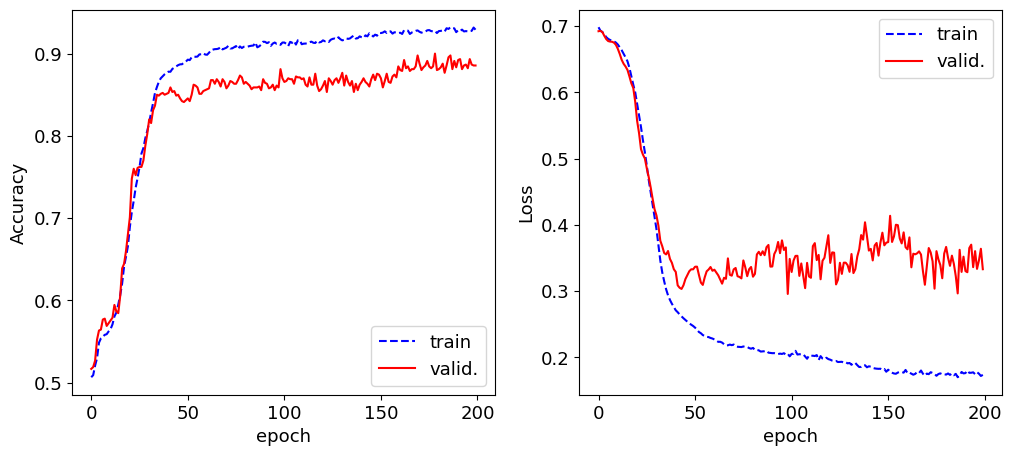

In [22]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# we want the train and valid to go toghether (is what we aim for), the signature of overfitting ids the gap between train and valid loss,
# in the case of underfitting we see that the accuracy does not increases.
# when our loss is around 0.7 we have a random number generator, we always strart from 0.7! (make the count we the cross entropy formula)

# Evaluation on the test set


In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4086
Final test accuracy: 0.8600


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


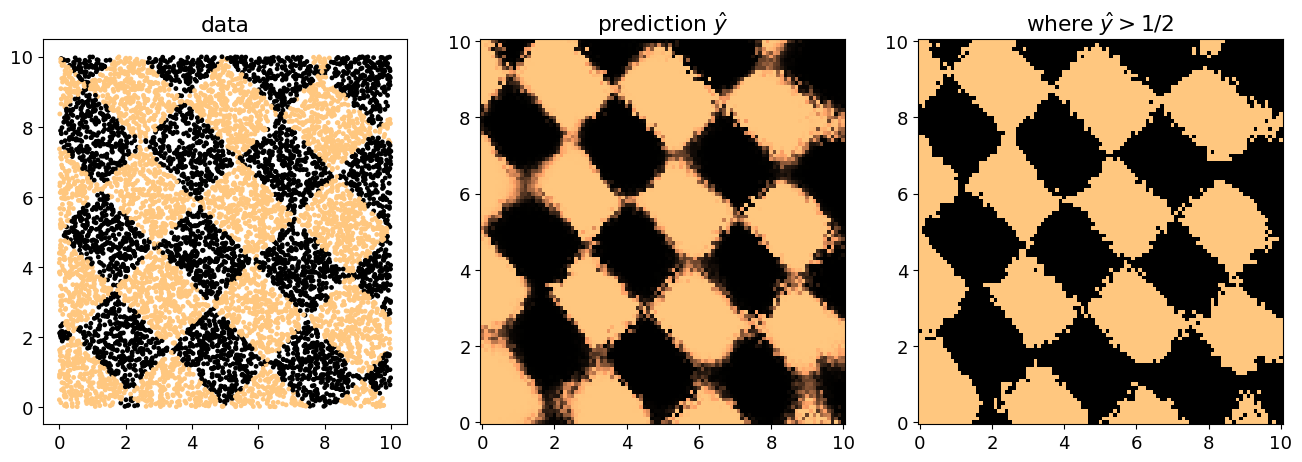

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [26]:
# we use neural network on a 10*10 grid, we create a colormap from 0 to 1 in fig 2 and a map we just 0 or 1 in fig 3
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

In [27]:
#assume we are in overfitting regim : we reduce parameters (reduce model capacity), randomize (through dropout), early stopping 
#(to be implement)
#assume we are underfitting regim : increase model capacity, less dropout, tune optimizer (learning rate)